<a href="https://colab.research.google.com/github/tmtngu/AITUAN7NHOM/blob/main/B%C3%B3i_Ch%E1%BB%89_Tay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

duong_dan="/content/drive/MyDrive/AI NHÓM TUẦN 7/30 dạng chỉ tay"
chieu_dai_anh,chieu_cao_anh=224,224
kich_thuoc_goi=32

train=tf.keras.utils.image_dataset_from_directory(
    duong_dan,
    labels='inferred',
    label_mode='categorical',
    image_size=(chieu_dai_anh,chieu_cao_anh),
    batch_size=kich_thuoc_goi,
    validation_split=0.2,
    subset='training',
    seed=123,
    crop_to_aspect_ratio=True)

loai_tay=train.class_names

test=tf.keras.utils.image_dataset_from_directory(
    duong_dan,
    labels='inferred',
    label_mode='categorical',
    image_size=(chieu_dai_anh,chieu_cao_anh),
    batch_size=kich_thuoc_goi,
    validation_split=0.2,
    subset='validation',
    seed=123,
    crop_to_aspect_ratio=True)

chuan_hoa=tf.keras.layers.Rescaling(1./255)
toi_uu=tf.data.AUTOTUNE

train=train.map(lambda x,y:(chuan_hoa(x),y)).cache().shuffle(1000).prefetch(buffer_size=toi_uu)
test=test.map(lambda x,y:(chuan_hoa(x),y)).cache().prefetch(buffer_size=toi_uu)

Found 1172 files belonging to 30 classes.
Using 938 files for training.
Found 1172 files belonging to 30 classes.
Using 234 files for validation.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt

so_loai=30
model=Sequential()

model.add(RandomFlip("horizontal",input_shape=(chieu_dai_anh,chieu_cao_anh,3)))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))

model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(so_loai,activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,243,358 (50.52 MB)

 Trainable params: 13,242,398 (50.52 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 344s 3s/step - accuracy: 0.1013 - loss: 4.0091 - val_accuracy: 0.0256 - val_loss: 4.6833
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.1802 - loss: 2.9473 - val_accuracy: 0.0256 - val_loss: 7.8803
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.2441 - loss: 2.7077 - val_accuracy: 0.0256 - val_loss: 10.9536
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.2687 - loss: 2.6099 - val_accuracy: 0.0256 - val_loss: 11.3147
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.3273 - loss: 2.3393 - val_accuracy: 0.0299 - val_loss: 11.1925
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.3539 - loss: 2.1845 - val_accuracy: 0.0299 - val_loss: 12.2070
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.4072 - loss: 2.0788 - val_accuracy: 0.0299 - val_loss: 15.2285
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.4232 - loss: 1.9950 - val_accuracy

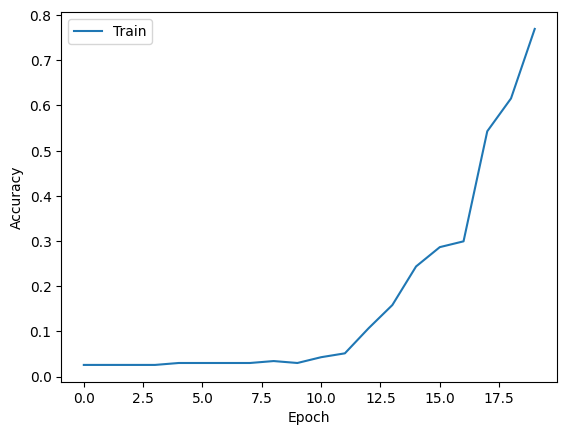

In [3]:
history=model.fit(
    train,
    epochs=20,
    validation_data=test)
plt.plot(history.history['val_accuracy'],label='ket qua')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()
model.save("/content/filetrainboichitaytmt.h5")

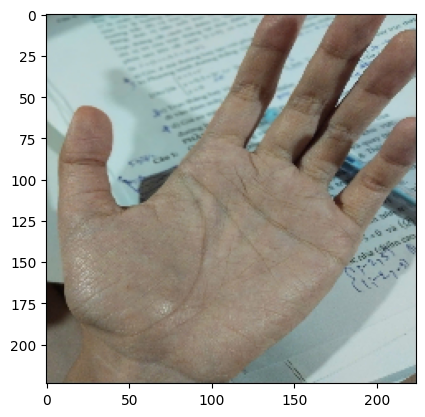

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Sâu sắc trong suy nghĩ, nhìn xa trông rộng.
Trái tim rộng mở, giao tiếp khéo léo.
Sức khỏe dồi dào, tinh thần ổn định.


In [12]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

CAUBOI={
    "001": ["Tư duy sắc bén, khả năng phân tích vấn đề tốt.", "Tâm đạo rộng mở, biết cách yêu thương và chia sẻ.", "Nguồn sinh lực dồi dào, tâm thế luôn chủ động."],
    "002": ["Tư duy linh hoạt, thích nghi nhanh với hoàn cảnh.", "Đời sống tình cảm êm đềm, luôn biết cách nhường nhịn.", "Sức khỏe bền bỉ, ít bị áp lực công việc làm ảnh hưởng."],
    "003": ["Trí tuệ minh mẫn, có khả năng lãnh đạo bẩm sinh.", "Tâm tính nhân hậu, luôn nhận được sự quý mến.", "Sinh đạo vững chắc, cuộc sống ít gặp trắc trở."],
    "004": ["Sáng tạo trong tư duy, luôn tìm ra giải pháp mới.", "Tình cảm chân thành, coi trọng sự gắn kết.", "Năng lượng sống tràn đầy, luôn lạc quan tiến tới."],
    "005": ["Quyết đoán và mạnh mẽ, không ngại khó khăn.", "Trái tim giàu lòng vị tha, dễ đồng cảm với người khác.", "Sức khỏe tốt, nền tảng sinh lực dồi dào."],
    "006": ["Tư duy logic, lập luận chặt chẽ trong công việc.", "Đời sống nội tâm sâu sắc, giàu lòng trắc ẩn.", "Sức sống dẻo dai, kiên trì theo đuổi mục tiêu."],
    "007": ["Khả năng quan sát tốt, chú trọng tiểu tiết.", "Tình cảm sâu đậm, luôn biết cách quan tâm người xung quanh.", "Năng lượng làm việc hiệu quả, đạt kết quả cao."],
    "008": ["Trí tuệ thông thái, luôn nhìn xa trông rộng.", "Tâm tính bình thản, ít khi nóng nảy.", "Sức khỏe dồi dào, tinh thần luôn ổn định."],
    "009": ["Nhạy bén, dễ dàng nắm bắt được cơ hội thành công.", "Tâm hồn rộng mở, dễ dàng kết giao bạn bè.", "Sức sống mạnh mẽ, luôn tràn đầy nhiệt huyết."],
    "010": ["Tự tin và bản lĩnh, làm chủ được cuộc sống.", "Trái tim ấm áp, mang lại bình yên cho mọi người.", "Nền tảng sinh lực vững chắc, cuộc đời nhiều may mắn."],
    "011": ["Tư duy sắc sảo, luôn có định hướng rõ ràng.", "Tính cách hòa đồng, dễ tạo thiện cảm.", "Nguồn năng lượng sống dồi dào, bền bỉ."],
    "012": ["Trí tuệ minh mẫn, khả năng học hỏi cao.", "Tâm tính ôn hòa, cuộc sống nhiều bình an.", "Sức khỏe ổn định, tinh thần luôn tươi mới."],
    "013": ["Sáng tạo và nhạy bén trong mọi công việc.", "Tình cảm chân thành, là chỗ dựa tin cậy.", "Năng lượng tràn đầy, luôn hướng về phía trước."],
    "014": ["Khả năng ra quyết định dứt khoát, bản lĩnh.", "Tâm đạo sâu sắc, giàu lòng vị tha.", "Nền tảng sức khỏe tốt, dẻo dai."],
    "015": ["Tư duy logic, giải quyết vấn đề hiệu quả.", "Tính cách ấm áp, biết quan tâm người khác.", "Sức sống mãnh liệt, ít bị ảnh hưởng bởi áp lực."],
    "016": ["Nhạy cảm với cơ hội, dễ gặt hái thành công.", "Đời sống nội tâm phong phú, nhiều cảm xúc.", "Năng lượng cân bằng, lối sống điều độ."],
    "017": ["Tự tin, quyết đoán trong mọi hoàn cảnh.", "Tình cảm chân thành, gắn kết bền chặt.", "Sức khỏe dồi dào, ít khi ốm đau vặt."],
    "018": ["Trí tuệ sáng suốt, nhìn xa trông rộng.", "Trái tim nhân hậu, được nhiều người yêu quý.", "Sức bền tốt, tinh thần luôn lạc quan."],
    "019": ["Sáng tạo độc đáo, tư duy khác biệt.", "Biết cách lắng nghe và thấu hiểu người khác.", "Năng lượng tích cực, luôn yêu đời."],
    "020": ["Bản lĩnh vững vàng, không ngại khó khăn.", "Tâm đạo ổn định, tình cảm hài hòa.", "Sức sống dẻo dai, bền bỉ cùng năm tháng."],
    "021": ["Tư duy mạch lạc, có kế hoạch rõ ràng.", "Đời sống nội tâm phong phú, giàu tình cảm.", "Sức khỏe ổn định, lối sống cân bằng."],
    "022": ["Khả năng quan sát tinh tế, chú trọng chi tiết.", "Tính cách kiên định, đáng tin cậy.", "Năng lượng dồi dào, sẵn sàng cho thử thách."],
    "023": ["Tư duy cởi mở, dễ thích nghi với môi trường mới.", "Tâm tính nhân hậu, hay giúp đỡ mọi người.", "Sức sống bền bỉ, ít khi gặp biến cố lớn."],
    "024": ["Sáng tạo trong công việc, tư duy khác biệt.", "Tình cảm chân thành, yêu ghét rõ ràng.", "Sức khỏe tốt, tinh thần luôn tươi mới."],
    "025": ["Quyết đoán và mạnh mẽ trong mọi lựa chọn.", "Đời sống cảm xúc mãnh liệt và sâu sắc.", "Có nguồn năng lượng sống dồi dào, ít mệt mỏi."],
    "026": ["Trí tuệ minh mẫn, học hỏi nhanh nhạy.", "Trái tim giàu lòng trắc ẩn, dễ đồng cảm.", "Cơ thể khỏe mạnh, nền tảng sinh lực tốt."],
    "027": ["Tư duy logic, lập luận chặt chẽ và khoa học.", "Đường tình duyên yên bình, hài hòa.", "Sức sống dẻo dai, bền bỉ qua thời gian."],
    "028": ["Nhạy bén với thời cơ, dễ gặt hái thành công.", "Tình cảm sâu đậm, biết cách kết nối.", "Năng lượng tràn đầy, làm việc hiệu quả."],
    "029": ["Sâu sắc trong suy nghĩ, nhìn xa trông rộng.", "Trái tim rộng mở, giao tiếp khéo léo.", "Sức khỏe dồi dào, tinh thần ổn định."],
    "030": ["Tự tin và bản lĩnh trong mọi hoàn cảnh.", "Đường đời rộng mở, tình cảm chân thành.", "Sức sống mãnh liệt, luôn tràn đầy nhiệt huyết."]
}
path="/content/z7894420971519_ae9ca4ae11cb17b90aadab0889d9f352.jpg"
img=load_img(path,target_size=(chieu_dai_anh,chieu_cao_anh))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/255.0
img=img.reshape(1,chieu_dai_anh,chieu_cao_anh,3)
pred=np.argmax(model.predict(img))
pred_id =f"{pred+1:03d}"
if pred_id in CAUBOI:
    for cau in CAUBOI[pred_id]:
        print(cau)